In [186]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler
import h5py

In [187]:
# Constants
METADATA_PATH = "/home/harinit9/orcd/pool/musicgen-data-nokey/dataset_metadata.json"
ACT_BATCHED_PATH = Path("/home/wyf/orcd/pool/musicgen-activations-nokey/activations_pooled")
ACTS_BY_LAYER_PATH = Path("/home/wyf/orcd/pool/musicgen-activations-nokey/acts_by_layer")

In [191]:
with open(METADATA_PATH) as fin:
    metadata = json.load(fin)

acts = np.load(ACTS_BY_LAYER_PATH / f"layer_00.npy", mmap_mode="r")

print(acts.shape)
print(f"{acts.nbytes:,} bytes")

(1000, 256, 2048)
2,097,152,000 bytes


In [192]:
print(acts[20])

[[-8.800078  -8.749403  -8.716991  ... -9.017574  -9.085928  -9.072513 ]
 [-8.955837  -8.82193   -8.869896  ... -9.124464  -8.986683  -9.086536 ]
 [-9.437149  -9.568295  -9.320814  ... -9.130386  -9.037526  -9.025654 ]
 ...
 [-9.058418  -9.151705  -9.626717  ... -9.00573   -9.005225  -8.906977 ]
 [-9.879288  -9.0918865 -8.966307  ... -9.080195  -8.979853  -8.9189825]
 [-9.851948  -9.832969  -8.070904  ... -8.925952  -9.026924  -9.051931 ]]


In [193]:
# Normalize per feature
acts_mean = acts.mean(axis=(1, 2), keepdims=True)
acts_std = acts.std(axis=(1, 2), keepdims=True) + 1e8

X_norm = (acts - acts_mean)
print(f"{X_norm.shape=}")

X_norm.shape=(1000, 256, 2048)


In [201]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128)
X_maxpool = np.max(acts, axis=1)
X_pca = pca.fit_transform(X_maxpool)

print(f"{X_pca.shape=}")

X_pca.shape=(1000, 128)


In [202]:
# Get labels
from sklearn.preprocessing import OneHotEncoder

all_keys = sorted(set([clip["key_info"]["mode"] for clip in metadata]))
n_classes = len(all_keys)

y_raw = np.array([
    all_keys.index(clip["key_info"]["mode"])
    for clip in metadata
])
y_onehot = np.eye(n_classes)[y_raw]
print(y_raw[:10])

[0 0 1 1 1 0 1 1 1 0]


In [203]:
# Make train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_raw, test_size=0.3, stratify=y_raw
)

print(f"{X_train.shape=}")
print(f"{X_test.shape=}")
print(f"{y_train.shape=}")
print(f"{y_test.shape=}")

X_train.shape=(700, 128)
X_test.shape=(300, 128)
y_train.shape=(700,)
y_test.shape=(300,)


(700, 128)


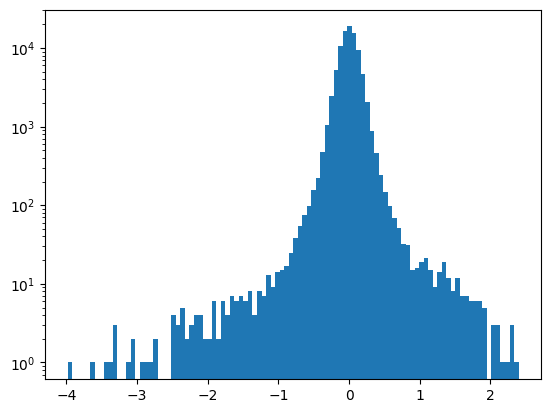

In [204]:
print(X_train.shape)
plt.hist(X_train.flatten(), bins=100);
plt.yscale("log")

In [205]:
# Train a linear probe
from sklearn.linear_model import LogisticRegression

reg = LogisticRegression(
    penalty="l2",
    C=100,
    max_iter=20_000,
)
reg.fit(X_train, y_train)

LogisticRegression(C=100, max_iter=20000)

TRAIN
Mean accuracy: 70.00


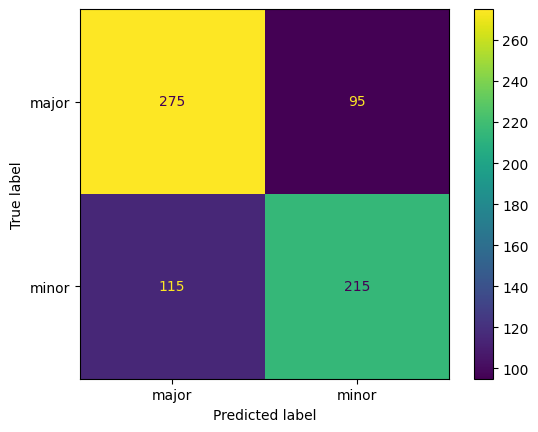

In [208]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

class_labels = ["major", "minor"]

def evaluate(X, y):
    y_pred = reg.predict(X) >= 0.5

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot()
    
    acc = accuracy_score(y, y_pred)
    print(f"Mean accuracy: {acc * 100:.2f}")

print(f"TRAIN")
evaluate(X_train, y_train)

TEST
Mean accuracy: 51.33


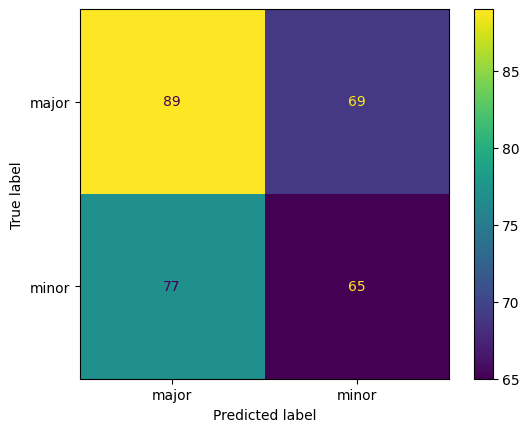

In [209]:
print(f"TEST")
evaluate(X_test, y_test)